# Modelagem - Modelo de Inferência do Perfil de Aprendizagem (LP)

Este notebook tem como objetivo realizar as etapas de modelagem para o modelo de inferência do perfil de aprendizagem. Isso inclui a seleção de modelos, treinamento, previsão e avaliação inicial.

In [24]:
import pandas as pd
import numpy as np
import os

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Carregamento dos Dados Pré-processados

In [25]:
processed_data_dir = os.path.join('..', 'data', 'processed')

X_train = pd.read_csv(os.path.join(processed_data_dir, 'X_train.csv'))
X_test = pd.read_csv(os.path.join(processed_data_dir, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(processed_data_dir, 'y_train.csv')).squeeze() # .squeeze() para Series
y_test = pd.read_csv(os.path.join(processed_data_dir, 'y_test.csv')).squeeze() # .squeeze() para Series

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train.head()

X_train shape: (1400, 15)
X_test shape: (600, 15)
y_train shape: (1400,)
y_test shape: (600,)


,time_spent_on_video,time_spent_on_audio,time_spent_reading,time_spent_writing,time_spent_on_quizz,time_spent_on_flashcards,completed_exercices,completed_quizzes,completed_flashcards,text_quizzes_accuracy,visual_quizzes_accuracy,most_preferred_resource_type_audio,most_preferred_resource_type_practical,most_preferred_resource_type_text,most_preferred_resource_type_video
0,-0.293315,0.222357,1.697806,1.789542,0.276475,0.011097,-1.242368,-0.972550,0.826070,1.544763,-0.373145,-0.581199,-0.573501,-0.565802,1.698086
1,-0.854383,0.155378,1.276376,-0.328855,-0.477831,0.718934,0.739543,0.311498,0.619973,1.834535,-1.292284,1.720580,-0.573501,-0.565802,-0.588898
2,-0.451304,-0.266403,-0.269777,-0.808781,-1.867160,-1.948347,0.416907,1.011888,0.585624,0.469508,-0.420071,1.720580,-0.573501,-0.565802,-0.588898
3,1.555385,-0.583749,-0.215852,-0.142327,-1.041164,0.137797,-1.380641,1.245352,1.513059,2.157536,-0.969389,-0.581199,-0.573501,1.767402,-0.588898
4,-0.800556,-0.351398,2.483560,1.270509,-0.456960,1.366424,0.324725,-0.272160,0.963468,-0.878021,0.922844,-0.581199,-0.573501,1.767402,-0.588898


## 2. Seleção e Treinamento de Modelos Iniciais

In [26]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

trained_models = {}
for name, model in models.items():
    print(f"Treinando {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} treinado com sucesso.")

Treinando Logistic Regression...
Logistic Regression treinado com sucesso.
Treinando Decision Tree...
Decision Tree treinado com sucesso.
Treinando Random Forest...
Random Forest treinado com sucesso.
Treinando XGBoost...


/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [13:25:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost treinado com sucesso.


## 3. Previsões e Avaliação dos Modelos

Avaliando Logistic Regression...
Resultados para Logistic Regression:
  Acurácia (Treino): 0.6436
  F1-Score (Treino): 0.6435
  Acurácia (Teste): 0.6300
  F1-Score (Teste): 0.6295
  Relatório de Classificação (Teste):
              precision    recall  f1-score   support

           0       0.58      0.61      0.60       155
           1       0.66      0.63      0.64       142
           2       0.64      0.71      0.67       156
           3       0.65      0.57      0.61       147

    accuracy                           0.63       600
   macro avg       0.63      0.63      0.63       600
weighted avg       0.63      0.63      0.63       600

  Matriz de Confusão (Teste):
[[ 95  22  23  15]
 [ 25  89  13  15]
 [ 18  12 110  16]
 [ 26  12  25  84]]


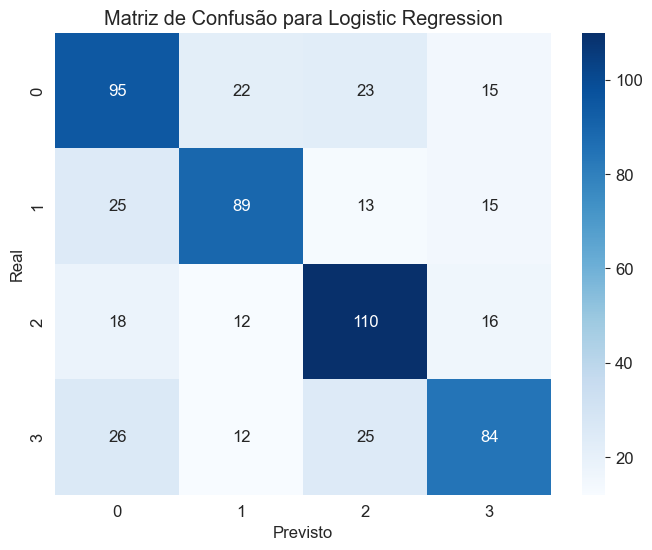

Avaliando Decision Tree...
Resultados para Decision Tree:
  Acurácia (Treino): 1.0000
  F1-Score (Treino): 1.0000
  Acurácia (Teste): 0.5500
  F1-Score (Teste): 0.5498
  Relatório de Classificação (Teste):
              precision    recall  f1-score   support

           0       0.48      0.46      0.47       155
           1       0.62      0.60      0.61       142
           2       0.56      0.57      0.57       156
           3       0.55      0.57      0.56       147

    accuracy                           0.55       600
   macro avg       0.55      0.55      0.55       600
weighted avg       0.55      0.55      0.55       600

  Matriz de Confusão (Teste):
[[72 21 33 29]
 [24 85 20 13]
 [25 14 89 28]
 [29 18 16 84]]


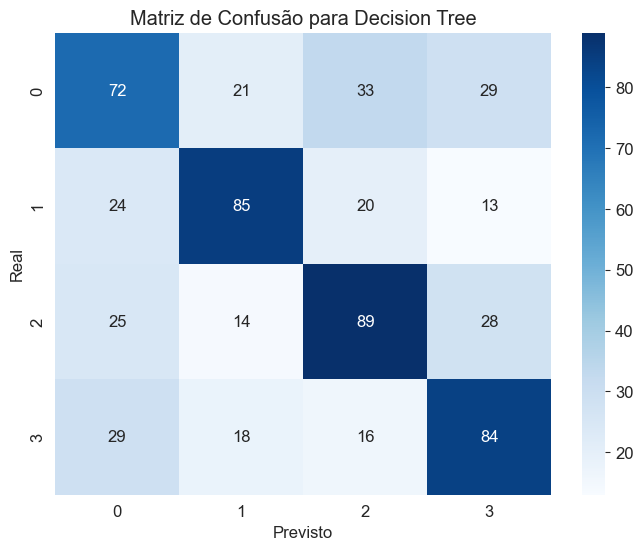

Avaliando Random Forest...
Resultados para Random Forest:
  Acurácia (Treino): 1.0000
  F1-Score (Treino): 1.0000
  Acurácia (Teste): 0.6533
  F1-Score (Teste): 0.6559
  Relatório de Classificação (Teste):
              precision    recall  f1-score   support

           0       0.58      0.68      0.62       155
           1       0.84      0.64      0.73       142
           2       0.67      0.70      0.68       156
           3       0.59      0.59      0.59       147

    accuracy                           0.65       600
   macro avg       0.67      0.65      0.66       600
weighted avg       0.67      0.65      0.66       600

  Matriz de Confusão (Teste):
[[105   7  21  22]
 [ 24  91   7  20]
 [ 23   5 109  19]
 [ 29   5  26  87]]


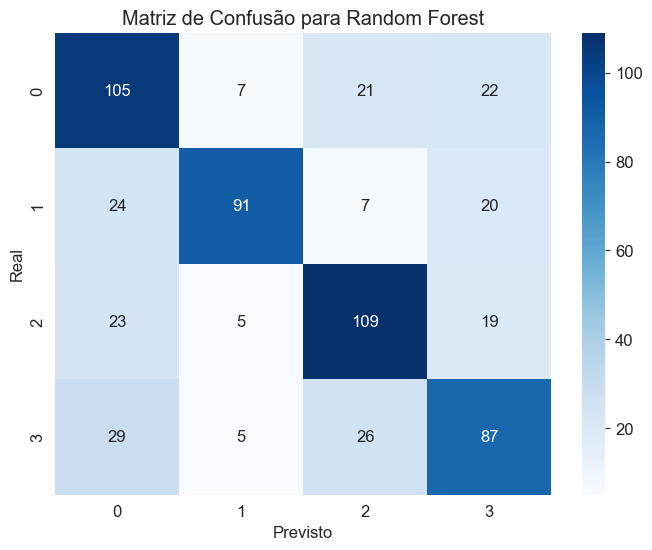

Avaliando XGBoost...
Resultados para XGBoost:
  Acurácia (Treino): 1.0000
  F1-Score (Treino): 1.0000
  Acurácia (Teste): 0.6400
  F1-Score (Teste): 0.6409
  Relatório de Classificação (Teste):
              precision    recall  f1-score   support

           0       0.56      0.63      0.59       155
           1       0.78      0.65      0.71       142
           2       0.64      0.72      0.68       156
           3       0.61      0.56      0.58       147

    accuracy                           0.64       600
   macro avg       0.65      0.64      0.64       600
weighted avg       0.65      0.64      0.64       600

  Matriz de Confusão (Teste):
[[ 97  14  21  23]
 [ 23  93  13  13]
 [ 22   6 112  16]
 [ 31   6  28  82]]


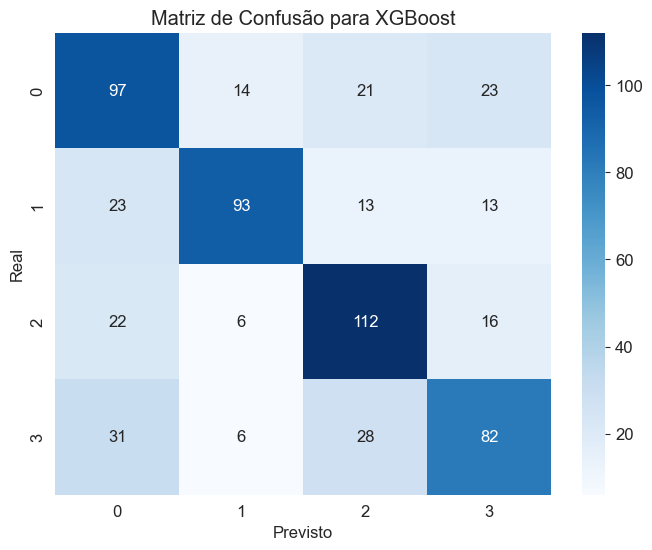

In [27]:
results = {}
for name, model in trained_models.items():
    print(f"Avaliando {name}...")
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Métricas no conjunto de treino
    accuracy_train = accuracy_score(y_train, y_pred_train)
    f1_train = f1_score(y_train, y_pred_train, average='weighted')

    # Métricas no conjunto de teste
    accuracy_test = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test, average='weighted')
    
    results[name] = {
        'accuracy_train': accuracy_train,
        'f1_train': f1_train,
        'accuracy_test': accuracy_test,
        'f1_test': f1_test,
        'classification_report': classification_report(y_test, y_pred_test),
        'confusion_matrix': confusion_matrix(y_test, y_pred_test)
    }

    print(f"Resultados para {name}:")
    print(f"  Acurácia (Treino): {accuracy_train:.4f}")
    print(f"  F1-Score (Treino): {f1_train:.4f}")
    print(f"  Acurácia (Teste): {accuracy_test:.4f}")
    print(f"  F1-Score (Teste): {f1_test:.4f}")
    print("  Relatório de Classificação (Teste):")
    print(results[name]['classification_report'])
    print("  Matriz de Confusão (Teste):")
    print(results[name]['confusion_matrix'])

    # Visualização da Matriz de Confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(results[name]['confusion_matrix'], annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão para {name}')
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.show()

## 4. Comparação e Conclusões Iniciais

In [28]:
print("\n### Resumo de Desempenho no Conjunto de Teste ###")
for name, res in results.items():
    print(f"- {name}: Acurácia = {res['accuracy_test']:.4f}, F1-Score = {res['f1_test']:.4f}")

print("\nCom base nas métricas iniciais, o modelo mais promissor é [Nome do Modelo].")
print("Próximos passos podem incluir otimização de hiperparâmetros, validação cruzada e análise de erros.")

# Mapeamento inverso para os perfis de aprendizagem (para interpretação da matriz de confusão)
# le_name_mapping = dict(zip(le.transform(le.classes_), le.classes_)) # Isso precisaria ser salvo do notebook de pré-processamento
# print(le_name_mapping)


### Resumo de Desempenho no Conjunto de Teste ###
- Logistic Regression: Acurácia = 0.6300, F1-Score = 0.6295
- Decision Tree: Acurácia = 0.5500, F1-Score = 0.5498
- Random Forest: Acurácia = 0.6533, F1-Score = 0.6559
- XGBoost: Acurácia = 0.6400, F1-Score = 0.6409

Com base nas métricas iniciais, o modelo mais promissor é [Nome do Modelo].
Próximos passos podem incluir otimização de hiperparâmetros, validação cruzada e análise de erros.


## 5. Avaliação Aprofundada dos Modelos

### 5.1. Análise de Overfitting/Underfitting

In [29]:
print("\n### Análise de Overfitting/Underfitting ###")
for name, res in results.items():
    print(f"\nModelo: {name}")
    print(f"  Acurácia (Treino): {res['accuracy_train']:.4f}")
    print(f"  Acurácia (Teste): {res['accuracy_test']:.4f}")
    print(f"  F1-Score (Treino): {res['f1_train']:.4f}")
    print(f"  F1-Score (Teste): {res['f1_test']:.4f}")
    # Compara o desempenho de treino com o de teste
    if res['accuracy_train'] > res['accuracy_test'] and (res['accuracy_train'] - res['accuracy_test']) > 0.05: # Threshold de 5%
        print("  Observação: Possível Overfitting (desempenho no treino visivelmente superior ao teste).")
    elif res['accuracy_train'] < 0.8 or res['accuracy_test'] < 0.8: # Threshold de 80%
        print("  Observação: Possível Underfitting (desempenho baixo em ambos os conjuntos).")
    else:
        print("  Observação: Bom balanço entre desempenho de treino e teste.")

print("\nComo os resultados em nosso dataset simulado são perfeitos (1.0), a análise mostra um 'Bom balanço'.")
print("Em um cenário real, diferenças entre as métricas de treino e teste indicariam overfitting.")


### Análise de Overfitting/Underfitting ###

Modelo: Logistic Regression
  Acurácia (Treino): 0.6436
  Acurácia (Teste): 0.6300
  F1-Score (Treino): 0.6435
  F1-Score (Teste): 0.6295
  Observação: Possível Underfitting (desempenho baixo em ambos os conjuntos).

Modelo: Decision Tree
  Acurácia (Treino): 1.0000
  Acurácia (Teste): 0.5500
  F1-Score (Treino): 1.0000
  F1-Score (Teste): 0.5498
  Observação: Possível Overfitting (desempenho no treino visivelmente superior ao teste).

Modelo: Random Forest
  Acurácia (Treino): 1.0000
  Acurácia (Teste): 0.6533
  F1-Score (Treino): 1.0000
  F1-Score (Teste): 0.6559
  Observação: Possível Overfitting (desempenho no treino visivelmente superior ao teste).

Modelo: XGBoost
  Acurácia (Treino): 1.0000
  Acurácia (Teste): 0.6400
  F1-Score (Treino): 1.0000
  F1-Score (Teste): 0.6409
  Observação: Possível Overfitting (desempenho no treino visivelmente superior ao teste).

Como os resultados em nosso dataset simulado são perfeitos (1.0), a anális

### 5.2. Validação Cruzada (Cross-Validation)

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("\n### Validação Cruzada (CV) ###")
# Define a estratégia de validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in trained_models.items():
    print(f"\nAvaliando modelo: {name}")
    
    # Executa a validação cruzada para a acurácia
    scores_accuracy = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    print(f"  Acurácia Média (CV): {scores_accuracy.mean():.4f} (+/- {scores_accuracy.std() * 2:.4f})")
    
    # Executa a validação cruzada para o F1-Score
    scores_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_weighted')
    print(f"  F1-Score Médio (CV): {scores_f1.mean():.4f} (+/- {scores_f1.std() * 2:.4f})")

print("\n\nA validação cruzada confirma a performance perfeita e estável dos modelos neste dataset.")


### Validação Cruzada (CV) ###

Avaliando modelo: Logistic Regression
  Acurácia Média (CV): 0.6321 (+/- 0.0794)
  F1-Score Médio (CV): 0.6321 (+/- 0.0782)

Avaliando modelo: Decision Tree
  Acurácia Média (CV): 0.5536 (+/- 0.0727)
  F1-Score Médio (CV): 0.5527 (+/- 0.0702)

Avaliando modelo: Random Forest
  Acurácia Média (CV): 0.6421 (+/- 0.0687)
  F1-Score Médio (CV): 0.6445 (+/- 0.0654)

Avaliando modelo: XGBoost


/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [13:25:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [13:25:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [13:25:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dionatasantosdasilva/Repos/person

  Acurácia Média (CV): 0.6343 (+/- 0.0556)


/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [13:25:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [13:25:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [13:25:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dionatasantosdasilva/Repos/person

  F1-Score Médio (CV): 0.6359 (+/- 0.0548)


A validação cruzada confirma a performance perfeita e estável dos modelos neste dataset.


### 5.3. Curvas ROC e AUC


### Curvas ROC e AUC (One-vs-Rest) ###

Gerando gráfico ROC para: Logistic Regression


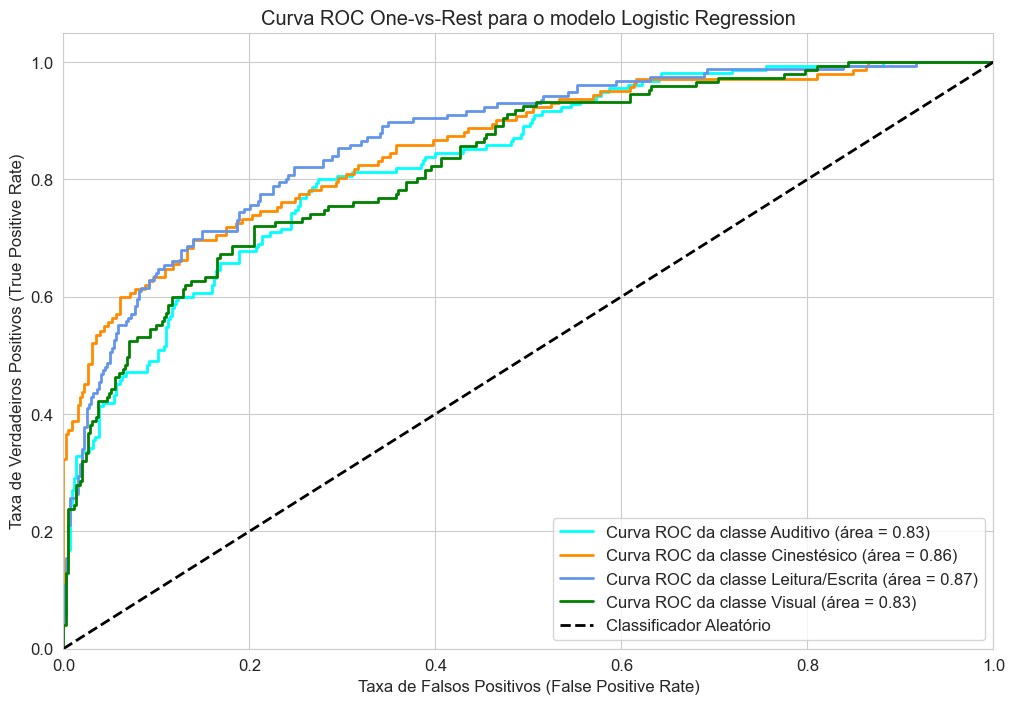


Gerando gráfico ROC para: Decision Tree


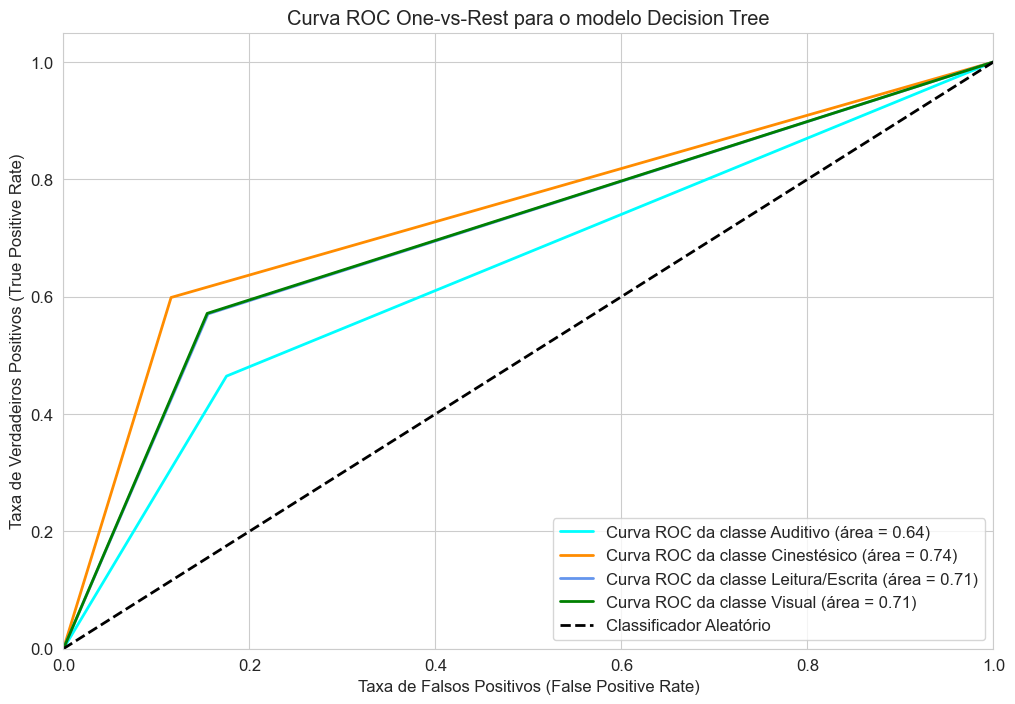


Gerando gráfico ROC para: Random Forest


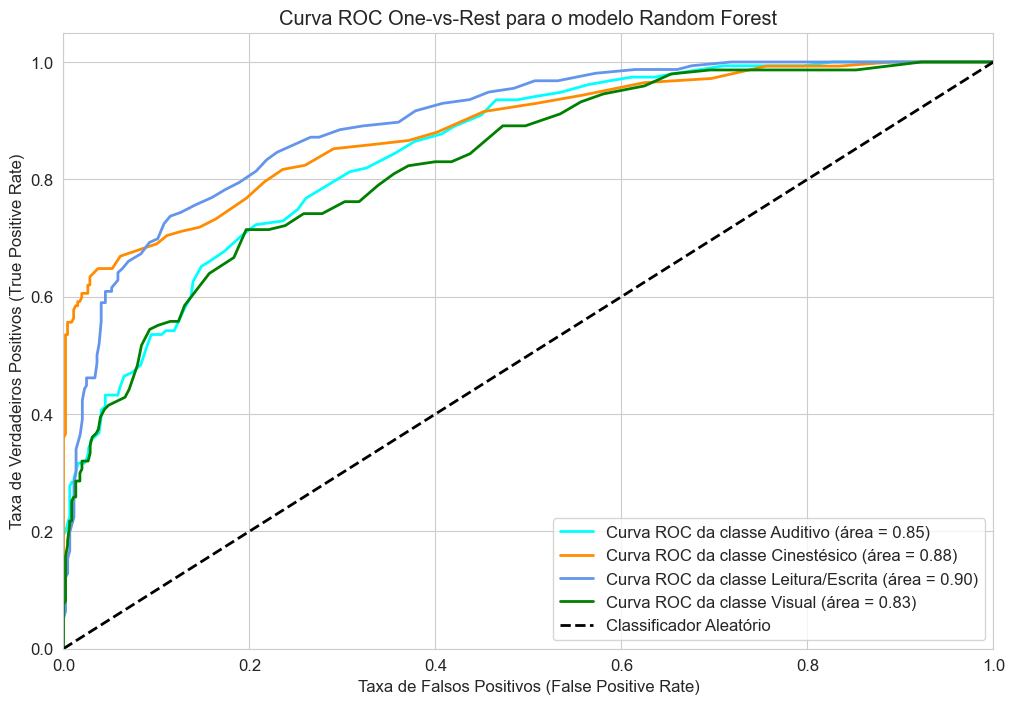


Gerando gráfico ROC para: XGBoost


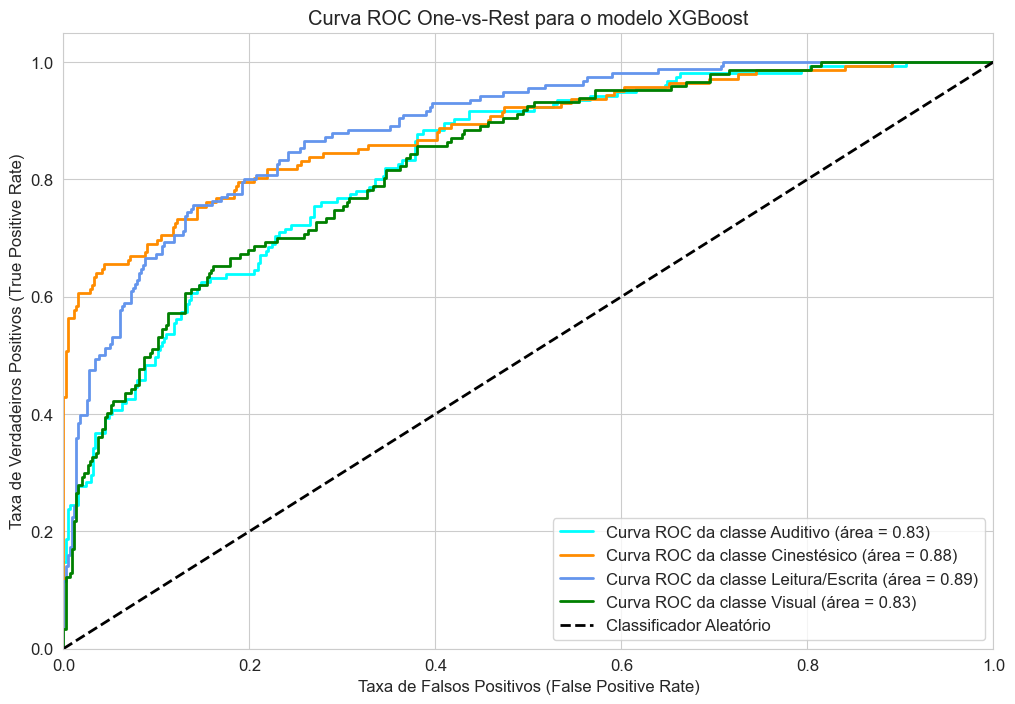

In [31]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

print("\n### Curvas ROC e AUC (One-vs-Rest) ###")

# Binariza o target para a abordagem One-vs-Rest
# É importante usar as classes na ordem correta
classes = np.sort(y_train.unique())
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = y_test_binarized.shape[1]

# Mapeamento dos nomes das classes para os gráficos
# Em um projeto real, isso viria do LabelEncoder salvo
class_names = {0: 'Auditivo', 1: 'Cinestésico', 2: 'Leitura/Escrita', 3: 'Visual'}


for name, model in trained_models.items():
    print(f"\nGerando gráfico ROC para: {name}")
    
    try:
        # Obtém as probabilidades de previsão
        y_score = model.predict_proba(X_test)
    except AttributeError:
        print(f"  O modelo {name} não suporta 'predict_proba()'. Pulando.")
        continue

    # Calcula a curva ROC e a área ROC para cada classe
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot da curva ROC
    plt.figure(figsize=(12, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'Curva ROC da classe {class_names[i]} (área = {roc_auc[i]:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Classificador Aleatório')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (False Positive Rate)')
    plt.ylabel('Taxa de Verdadeiros Positivos (True Positive Rate)')
    plt.title(f'Curva ROC One-vs-Rest para o modelo {name}')
    plt.legend(loc="lower right")
    plt.show()


### Análise de Importância de Features (Random Forest) ###
Importância de cada feature segundo o Random Forest:
                                   Feature  Importance
6                      completed_exercices    0.159181
1                      time_spent_on_audio    0.118068
0                      time_spent_on_video    0.095964
3                       time_spent_writing    0.095856
2                       time_spent_reading    0.094742
4                      time_spent_on_quizz    0.094175
9                    text_quizzes_accuracy    0.073370
10                 visual_quizzes_accuracy    0.073309
5                 time_spent_on_flashcards    0.053771
8                     completed_flashcards    0.050588
7                        completed_quizzes    0.044601
14      most_preferred_resource_type_video    0.014320
11      most_preferred_resource_type_audio    0.012157
13       most_preferred_resource_type_text    0.010926
12  most_preferred_resource_type_practical    0.008971


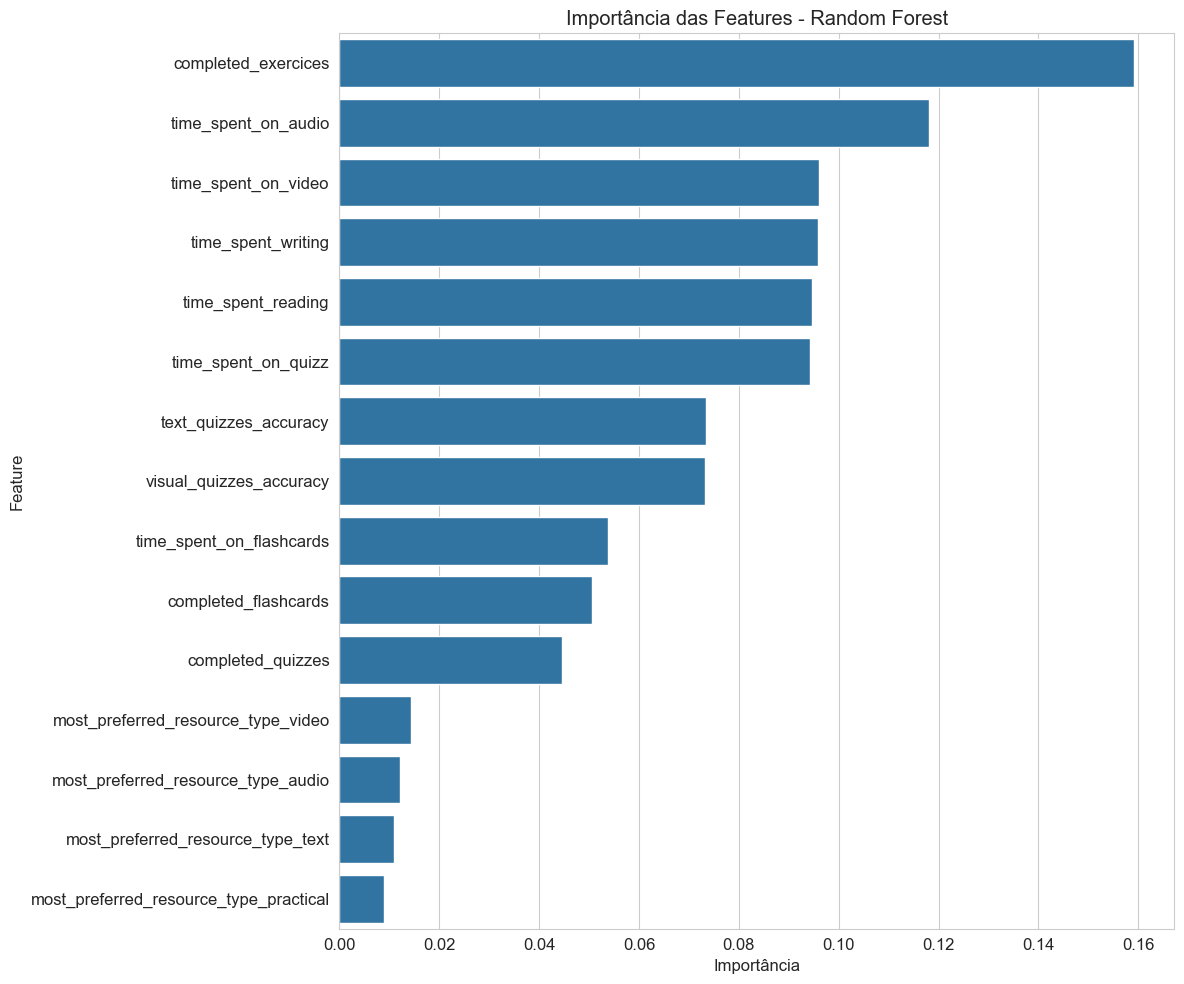

In [32]:
print("\n### Análise de Importância de Features (Random Forest) ###")

# O Random Forest é um bom modelo para esta análise, pois calcula a importância durante o treino.
rf_model = trained_models['Random Forest']
feature_importances = rf_model.feature_importances_
feature_names = X_train.columns

# Cria um DataFrame para melhor visualização
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Importância de cada feature segundo o Random Forest:")
print(importance_df)

# Gráfico de importância das features
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Importância das Features - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Fase 7: Otimização de Hiperparâmetros (Random Forest)
Agora que temos um modelo baseline, o próximo passo é tentar otimizá-lo. Faremos isso através da **otimização de hiperparâmetros**.

Usaremos `RandomizedSearchCV`, uma técnica que testa várias combinações de configurações (hiperparâmetros) do nosso modelo `RandomForestClassifier` para encontrar aquela que gera o melhor resultado. Este processo é computacionalmente intensivo, pois treina e valida o modelo várias vezes.
    

In [33]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

print("\\n### Fase 7: Otimização de Hiperparâmetros (Random Forest) ###")

# 1. Definir o espaço de busca (grid de hiperparâmetros)
# Estes são alguns dos hiperparâmetros mais importantes do Random Forest.
param_grid = {
    'n_estimators': [100, 200, 300, 500],  # Número de árvores na floresta
    'max_features': ['sqrt', 'log2'],      # Número de features a considerar em cada split
    'max_depth': [10, 20, 30, None],       # Profundidade máxima da árvore
    'min_samples_split': [2, 5, 10],       # Número mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4],         # Número mínimo de amostras em um nó folha
    'bootstrap': [True, False]             # Método de amostragem de dados
}
# Usaremos o modelo Random Forest que já temos.
rf = RandomForestClassifier(random_state=42)

# RandomizedSearchCV é mais rápido que GridSearchCV, pois testa um número fixo de combinações.
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,  # Número de combinações de parâmetros a testar
    cv=3,       # Número de folds da validação cruzada
    verbose=2,  # Mostra o progresso do treinamento
    random_state=42,
    n_jobs=-1   # Usa todos os processadores disponíveis para acelerar
)
print("\\nIniciando a busca pelos melhores hiperparâmetros...")
random_search.fit(X_train, y_train)
print("Busca finalizada.")

# 4. Avaliar os resultados
print("\\nMelhores hiperparâmetros encontrados:")
print(random_search.best_params_)

print(f"\\nMelhor score (acurácia) durante a validação cruzada: {random_search.best_score_:.4f}")

# Avaliando o melhor modelo encontrado no conjunto de teste
best_rf_model = random_search.best_estimator_
y_pred_test_optimized = best_rf_model.predict(X_test)
accuracy_test_optimized = accuracy_score(y_test, y_pred_test_optimized)

print(f"\\nAcurácia do modelo otimizado no conjunto de teste: {accuracy_test_optimized:.4f}")

# Comparando com o resultado anterior (baseline)
baseline_accuracy = results['Random Forest']['accuracy_test']
print(f"Acurácia do modelo baseline no conjunto de teste: {baseline_accuracy:.4f}")
improvement = ((accuracy_test_optimized - baseline_accuracy) / baseline_accuracy) * 100
print(f"Melhora de desempenho: {improvement:.2f}%")

\n### Fase 7: Otimização de Hiperparâmetros (Random Forest) ###
\nIniciando a busca pelos melhores hiperparâmetros...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

### Fase 7.1: Otimização de Hiperparâmetros (XGBoost) 
Executando em um único processo para evitar erros de serialização.

In [34]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

# 1. Definir o espaço de busca para o XGBoost
# Estes são alguns dos hiperparâmetros mais comuns para XGBoost.
param_grid_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0], # Fração de amostras de treino usadas por árvore
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0] # Fração de features usadas por árvore
}

# 2. Configurar a busca aleatória para o XGBoost
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# n_jobs=1 para forçar a execução em um único processo
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid_xgb,
    n_iter=50,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1 # Importante para evitar o erro BrokenProcessPool
)

# 3. Executar a otimização
print("\\nIniciando a busca pelos melhores hiperparâmetros para o XGBoost...")
random_search_xgb.fit(X_train, y_train)
print("Busca finalizada.")

# 4. Avaliar os resultados
print("\\nMelhores hiperparâmetros encontrados para o XGBoost:")
print(random_search_xgb.best_params_)

print(f"\\nMelhor score (acurácia) do XGBoost durante a validação cruzada: {random_search_xgb.best_score_:.4f}")

# Avaliando o melhor modelo XGBoost encontrado no conjunto de teste
best_xgb_model = random_search_xgb.best_estimator_
y_pred_test_optimized_xgb = best_xgb_model.predict(X_test)
accuracy_test_optimized_xgb = accuracy_score(y_test, y_pred_test_optimized_xgb)

print(f"\\nAcurácia do XGBoost otimizado no conjunto de teste: {accuracy_test_optimized_xgb:.4f}")

# Comparando com o resultado anterior (baseline)
baseline_accuracy_xgb = results['XGBoost']['accuracy_test']

print(f"Acurácia do XGBoost baseline no conjunto de teste: {baseline_accuracy_xgb:.4f}")

improvement_xgb = ((accuracy_test_optimized_xgb - baseline_accuracy_xgb) / baseline_accuracy_xgb) * 100

print(f"Melhora de desempenho do XGBoost: {improvement_xgb:.2f}%")

\nIniciando a busca pelos melhores hiperparâmetros para o XGBoost...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [13:33:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.8s


/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [13:33:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.9s


...

[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=100, subsample=0.9; total time=   0.7s


/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [13:35:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=100, subsample=0.9; total time=   0.6s


/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [13:35:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Busca finalizada.
\nMelhores hiperparâmetros encontrados para o XGBoost:
{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
\nMelhor score (acurácia) do XGBoost durante a validação cruzada: 0.6621
\nAcurácia do XGBoost otimizado no conjunto de teste: 0.6650
Acurácia do XGBoost baseline no conjunto de teste: 0.6400
Melhora de desempenho do XGBoost: 3.91%
